In [13]:
import sys
sys.path.insert(0, "/home/aronw/Development/Clans-3D")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import Scores_Evaluation.ScoresEvaluator as SE
from InputFileType import InputFileType
from ToolType import ToolType

In [18]:
WORKING_DIR = "/home/aronw/Development/Clans-3D/Scores_Evaluation"
EXAMPLE_DATASET_FASTA = "/home/aronw/Development/Clans-3D/example_files/small_fasta_files/50.fasta"
EXAMPLE_DATASET_TSV = "/home/aronw/Development/Clans-3D/example_files/big_tsv_files/1500.tsv"

In [19]:
evaluator = SE.ScoresEvaluator(WORKING_DIR)

In [20]:
clans_files = evaluator.generate_clans_files(EXAMPLE_DATASET_TSV, InputFileType.TSV, ToolType.FOLDSEEK, "evalue")
print(clans_files)

EmptyDataError: No columns to parse from file

In [ ]:
# Parameters for clustering recovered clans. The first entry in each tuple is for structure-based clans, the second for sequence-based clans.
PATH_TO_CLANS_JAR = "/home/aronw/Development/Clans-3D/recovered_CLANS/clans_working_version.jar" # path to clans jar file
CLUSTER_ROUNDS: tuple[int, int] = (10000, 10000) # sets the number of rounds for clustering in recovered clans
P_VALUES: tuple[float, float] = (1E-10, 1E-29) # sets the p-value threshold for clustering in recovered clans for (structure, sequence)
CLUSTER_2D: tuple[bool, bool] = (False, False) # whether to use 2D clustering in recovered clans
VERBOSE: bool = True # whether to print verbose output from recovered clans

In [ ]:
clustered_clans_files = evaluator.cluster_clans_files(PATH_TO_CLANS_JAR, clans_files, CLUSTER_ROUNDS, P_VALUES, CLUSTER_2D, VERBOSE)
print(clustered_clans_files)

In [7]:
import Scores_Evaluation.ScoresEvaluator as SE
evaluator = SE.ScoresEvaluator(WORKING_DIR)
clustered_clans_files = ("/home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_clustered_r_10000_p_1e-10.clans",
                         "/home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_seq_clustered_r_10000_p_1e-29.clans")

In [8]:
df_scores, df_euclidean_dist, df_coord = evaluator.extract_data_from_clans_files(clustered_clans_files)
print(df_scores.head())
print(df_euclidean_dist.head())
print(df_coord.head())


Evaluating clustered clans files: /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_clustered_r_10000_p_1e-10.clans and /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_seq_clustered_r_10000_p_1e-29.clans
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_clustered_r_10000_p_1e-10.clans...
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_seq_clustered_r_10000_p_1e-29.clans...
   Sequence_ID_1  Sequence_ID_2  Score_struct  Score_-log10_struct  \
0              0              1  5.263000e-10             9.278767   
1              0              2  2.115000e-09             8.674690   
2              0              3  5.874000e-09             8.231066   
3              0              4  2.520000e-07             6.598599   
4              0              5  4.175000e-07             6.379344   

      Score_seq  Score_-log10_seq  
0  2.120000e-44         43.673664  
1  1.200000e-38         37.920819  


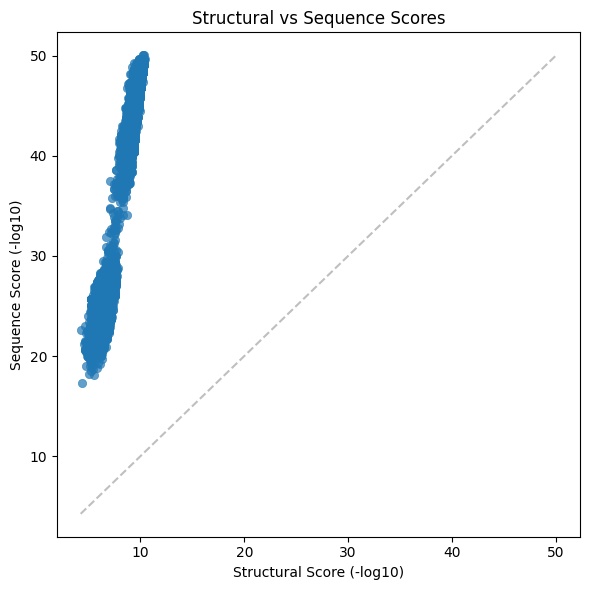

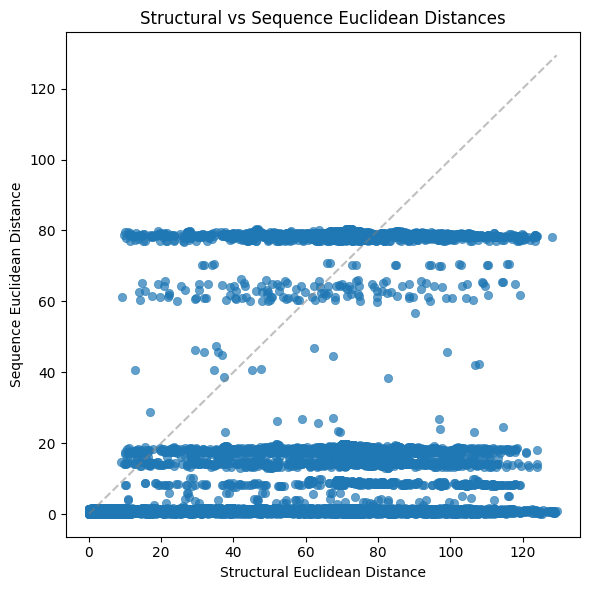

In [12]:
evaluator.generate_scatter_plot(
    data_x=df_scores["Score_-log10_struct"],
    data_y=df_scores["Score_-log10_seq"],
    x_label="Structural Score (-log10)",
    y_label="Sequence Score (-log10)",
    title="Structural vs Sequence Scores"
)

evaluator.generate_scatter_plot(
    data_x=df_euclidean_dist["euclidean_dist_struct"],
    data_y=df_euclidean_dist["euclidean_dist_seq"],
    x_label="Structural Euclidean Distance",
    y_label="Sequence Euclidean Distance",
    title="Structural vs Sequence Euclidean Distances"
)

In [ ]:
df_cluster_labels = evaluator.find_clusters_density_based(df_coord, "struct")
df_cluster_labels = df_cluster_labels.merge(evaluator.find_clusters_density_based(df_coord, "seq"), on="Sequence_ID")
df_Leiden_labels = evaluator.find_clusters_graph_based(df_scores, "Score_-log10_struct")
df_Leiden_labels = df_Leiden_labels.merge(evaluator.find_clusters_graph_based(df_scores, "Score_-log10_seq"), on="Sequence_ID")
df_cluster_labels = df_cluster_labels.merge(df_Leiden_labels, on="Sequence_ID")

In [11]:
df_cluster_labels

,Sequence_ID,cluster_id_struct_DBSCAN,cluster_id_seq_DBSCAN,cluster_id_Score_-log10_struct_Leiden,cluster_id_Score_-log10_seq_Leiden
0,0,-1,-1,1,1
1,1,-1,-1,1,1
2,2,-1,-1,1,1
3,3,-1,-1,1,1
4,4,-1,0,1,1
...,...,...,...,...,...
488,488,-1,0,1,1
489,489,-1,0,1,1
490,490,-1,0,1,1
491,491,-1,-1,1,1
